## Interactive Bayesian Optimization (w/UCB Acquisition) for Function 8

Note: This code recommends the next point based on historical data.

Submit the recommended point to the Capstone project portal, obtain the output, then update `input.npy` and `output.npy`.

Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
# from sklearn.gaussian_process.kernels import ConstantKernel
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Input
from scipy.stats import norm
import random
import os

In [2]:
# Load and check initial data

# Initial INPUT file path
X_init = np.load(r"initial_data\function_8\initial_inputs.npy")
# Initial OUTPUT file path
y_init = np.load(r"initial_data\function_8\initial_outputs.npy")

# INPUT file storing historical inputs 8D array (n, dim)
input_file = r"initial_data\function_8\inputs.npy"
# OUTPUT file storing historical outputs 1D array (n, )
output_file = r"initial_data\function_8\outputs.npy"

if os.path.exists(input_file) and os.path.exists(output_file):
    print(f"Historical INPUT contains {len(np.load(input_file))} points:\n", np.load(input_file))
    print(f"Historical OUTPUT contains {len(np.load(output_file))} points:\n", np.load(output_file))
else:
    print(f"Initial INPUT contains {len(X_init)} points:\n", X_init)
    print(f"Initial INPUT contains {len(y_init)} points:\n", y_init)

Historical INPUT contains 45 points:
 [[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.596598

In [3]:
# 1. Configuration

# INPUT dimensionality
dim = 8
len_init = len(X_init)

# Bounds for each dimension
bounds = np.array([[0, 0.999999]] * dim)

# Number of candidate points
n_candidates = 20000

rbf_lengthscale = 0.1
noise_assumption = 1e-10
beta = 1.96
random.seed(23)
np.random.seed(23)

search_model = 'gp'    # 'gp' or 'nn'

In [4]:
# 2. Helper functions

# Load historical data from input.npy and output.npy
def load_data():
    if os.path.exists(input_file) and os.path.exists(output_file):
        print("Load historical data")
        X = np.load(input_file)
        y = np.load(output_file)
        # ensure dimensions match
        if X.shape[0] != y.shape[0]:
            raise ValueError(f"input.npy and output.npy mismatch: {X.shape[0]} vs {y.shape[0]}")
        return X, y
    else:
        print("Load initial data")
        X = X_init
        y = y_init
        return X, y

# Save historical data to input.npy and output.npy
def save_data(X, y):
    np.save(input_file, X)
    np.save(output_file, y)

# Upper Confidence Bound (UCB) acquisition function
def ucb_acquisition(x_cand, model, beta):
    post_mean, post_std = model.predict(x_cand, return_std = True)
    # avoid zero standard deviation
    post_std = np.maximum(post_std, 1e-9)
    return post_mean + beta * post_std

# Recommend the next point to evaluate
def suggest_next_point(X, y, trust_region, beta):
    kernel = RBF(length_scale = rbf_lengthscale, length_scale_bounds = (0.01, 10.0)) \
             + WhiteKernel(noise_level = 1e-10, noise_level_bounds = 'fixed')
    model = GaussianProcessRegressor(kernel = kernel, alpha = 0.0, normalize_y = True, n_restarts_optimizer = 5)
    model.fit(X, y)
    
    # Generate candidate points
    #candidates = np.random.uniform(bounds[:, 0], bounds[:, 1], size = (n_candidates, dim))
    candidates = samples_in_trust_region(trust_region, n_candidates)
    
    # Exclude points that have already been evaluated
    from sklearn.neighbors import NearestNeighbors
    neighbors = NearestNeighbors(n_neighbors = 1, algorithm = 'auto').fit(X)
    distances, _ = neighbors.kneighbors(candidates)
    mask = distances.flatten() > 1e-6
    candidates = candidates[mask]

    print("Use Upper Confidence Bound (UCB) acquisition function within Trust Region.")
    ucb_values = ucb_acquisition(candidates, model, beta)
    next_idx = np.argmax(ucb_values)
    x_next = candidates[next_idx]
    mean, std = model.predict(x_next.reshape(1,-1), return_std = True)
    print(f"Predicted mean = {mean.item():.6f}, std = {std.item():.6f}, UCB = {mean.item() + beta * std.item():.6f}")
    return x_next, ucb_values[next_idx]

# Plot optimization progress
def plot_progress(X, y, beta):
    #best_so_far = np.maximum.accumulate(y)
    plt.figure(figsize = (8, 4))
    #plt.plot(range(1, len(best_so_far) + 1), best_so_far, 'b-o', markersize = 4)
    plt.plot(range(1, len(y) + 1), y, 'b-o', markersize = 4)
    plt.xlabel('Number of evaluations')
    #plt.ylabel('Best Output found so far')
    plt.ylabel('Every Output found so far')
    plt.title('Optimization Progress (UCB, β={})'.format(beta, beta))
    plt.grid(True)
    plt.show()

# Convert an integer into its ordinal string
def ordinal(n):
    if 10 <= n % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f"{n}{suffix}"

**Apr. 28<sup>th</sup>** (before 4<sup>th</sup> submission)

- Define functions to implement the Trust Region approach. <br>Based on the current optimal output point, define a hypercube Trust Region. If the optimal outputs improve continuously, expand the radius; if no improvement, reduce the radius.

In [5]:
trust_region_file = r"initial_data\function_8\trust_region.npy"

def load_trust_region(X, y, filename = trust_region_file):
    if os.path.exists(filename):
        region = np.load(filename, allow_pickle = True).item()
        best_so_far = X[np.argmax(y)]
        if not np.array_equal(region['center'], best_so_far):
            region['center'] = best_so_far.copy()
        return region
    else:
        center = X[np.argmax(y)]
        print("Create initial Trust Region.")
        return {
            'center': center.copy(),
            'radius': 0.1,
            'bounds': bounds,
            'improvement_counter': 0,
            'unimprovement_counter': 0
        }

'''
def init_trust_region(center, radius = 0.1, bounds = bounds):
    return {
        'center': center.copy(),
        'radius': radius,
        'bounds': bounds,
        'improvement_counter': 0,
        'unimprovement_counter': 0
    }
'''

def save_trust_region(region, filename = trust_region_file):
    region_to_save = {
        'center': region['center'],
        'radius': region['radius'],
        'bounds': region['bounds'],
        'improvement_counter': region['improvement_counter'],
        'unimprovement_counter': region['unimprovement_counter']
    }
    np.save(filename, region_to_save, allow_pickle=True)
    print("Trust Region file is updated.")


def update_trust_region(region, new_center, improved = False):
    region['center'] = new_center.copy()
    if improved:
        region['improvement_counter'] += 1
        region['unimprovement_counter'] = 0
        if region['improvement_counter'] >= 2:
            region['radius'] *= factor
            print(f"Trust Region shrunk to radius {region['radius']:.4f}")
            region['improvement_counter'] = 0
    else:
        region['unimprovement_counter'] += 1
        region['improvement_counter'] = 0
        if region['unimprovement_counter'] >= 2:
            region['radius'] = min(region['radius'] * 1.5, 0.5)
            print(f"Trust Region expanded to radius {region['radius']:.4f}")
            region['unimprovement_counter'] = 0
    save_trust_region(region)

def samples_in_trust_region(region, n_points):
    n_local = int(n_points * 0.2)
    n_global = n_points - n_local
    lower = np.maximum(region['center'] - region['radius'], region['bounds'][:, 0])
    upper = np.minimum(region['center'] + region['radius'], region['bounds'][:, 1])
    lower = np.clip(lower, region['bounds'][:, 0], region['bounds'][:, 1])
    upper = np.clip(upper, region['bounds'][:, 0], region['bounds'][:, 1])
    local_samples = np.random.uniform(lower, upper, size = (n_local, dim))
    global_samples = np.random.uniform(region['bounds'][:, 0], region['bounds'][:,1], size = (n_global, dim))
    return np.vstack([local_samples, global_samples])

**Apr. 28<sup>th</sup>** (before 4<sup>th</sup> submission)

- Define functions to implement Neural Network. <br>

In [6]:
tf.random.set_seed(23)

def build_nn_model():
    model = tf.keras.Sequential([
        Input(shape = (dim,)),
        tf.keras.layers.Dense(64, activation = 'relu'),
        tf.keras.layers.Dense(32, activation = 'relu'),
        tf.keras.layers.Dense(1)
    ])
    return model

def suggest_by_nn(X, y, trust_region, epochs = 200, n_restarts = 5, n_steps = 50, learning_rate = 0.1):
    print('Use neural network for exploration.')
    # standardize output
    y_scaler = StandardScaler()
    y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).flatten()

    # train model
    model = build_nn_model()
    model.compile(optimizer = tf.keras.optimizers.SGD(learning_rate = learning_rate),
                  loss = tf.keras.losses.MeanSquaredError())
    model.fit(X, y_scaled, epochs = epochs, verbose = 0)

    mean_y = y_scaler.mean_[0]
    scale_y = y_scaler.scale_[0]
    
    def gradient_ascent(x_start):
        x = tf.Variable(x_start.reshape(1, -1), dtype = tf.float32)
        for _ in range(n_steps):
            with tf.GradientTape() as tape:
                mean_scaled = model(x, training = False)[0, 0]
                mean = mean_scaled * scale_y + mean_y
                ucb = mean + beta * 0.1
            grads = tape.gradient(ucb, x)
            x.assign_add(0.01 * grads)
            x.assign(tf.clip_by_value(x, trust_region['bounds'][:, 0], trust_region['bounds'][:, 1]))
        return x.numpy()[0]

    x_next = None
    best_acquisition_value = -np.inf
    for _ in range(n_restarts):
        lower = np.maximum(trust_region['center'] - trust_region['radius'], trust_region['bounds'][:, 0])
        upper = np.minimum(trust_region['center'] + trust_region['radius'], trust_region['bounds'][:, 1])
        if np.any(upper <= lower):
            x_start = np.random.uniform(trust_region['bounds'][:, 0], trust_region['bounds'][:, 1])
        else:
            x_start = np.random.uniform(lower, upper)
        x_opt = gradient_ascent(x_start)

        # calculate UCB
        mean_scaled = model.predict(x_opt.reshape(1, -1), verbose = 0)[0, 0]
        mean = mean_scaled * scale_y + mean_y
        acquisition_value = mean + beta * 0.1
        if acquisition_value > best_acquisition_value:
            best_acquisition_value = acquisition_value
            x_next = x_opt
    print(f"Predicted mean = {mean:.6f}, constant std = 0.1, UCB = {mean + beta * 0.1}")
    return x_next, best_acquisition_value

Load historical data
Loaded 45 points. And the historical OUTPUT:
 [7.3987211  7.00522736 8.45948162 8.28400781 8.60611679 8.54174792
 7.32743458 7.29987205 7.95787474 5.59219339 7.85454099 6.79198578
 8.97655402 7.3790829  9.598482   8.15998319 7.13162397 6.76796253
 7.43374407 9.01307515 7.31089382 5.84106731 9.14163949 8.81755844
 6.45194313 8.83074505 9.34427428 6.88784639 8.04221254 7.69236805
 7.92375877 8.42175924 8.2780624  7.11345716 6.40258841 8.47293632
 7.97768459 7.46087219 7.43659353 9.18300525 8.28463912 9.09633749
 9.26385796 9.75391701 9.6894535 ]
Current best output: 9.753917


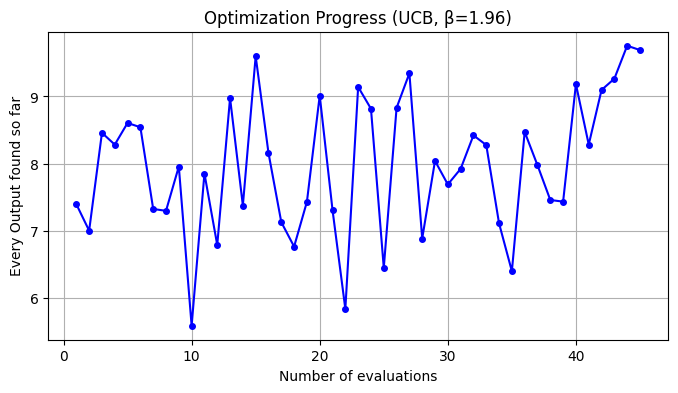

In [7]:
# 3. Load historical data and view current status
X, y = load_data()

print(f"Loaded {len(X)} points. And the historical OUTPUT:\n", y)

if len(y) > 0:
    previous_best = np.max(y)
    print(f"Current best output: {np.max(y):.6f}")
    plot_progress(X, y, beta)
else:
    print("Please load initial data")

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

Check whether the optimal output has been unimproved over several queries. If yes, execute the grid research function.

In [8]:
# 4. Recommend the next point to submit

trust_region = load_trust_region(X, y)
print(f"Trust region center: {trust_region['center']}, radius: {trust_region['radius']:.4f}")

if search_model == 'gp':
    x_next, best_acquisition_value = suggest_next_point(X, y, trust_region, beta)
    print(f"GP selected point with acquisition value: {best_acquisition_value:.6f}")
elif search_model == 'nn':
    x_next, best_acquisition_value = suggest_by_nn(X, y, trust_region)
    print(f"Neural network selected point with acquisition value: {best_acquisition_value:.6f}")
else:
    raise ValueError("search_model must be 'gp' or 'nn'")

submit_next = len(X) - len_init + 1
print(f"The {ordinal(submit_next)} recommended input point:")
print(np.round(x_next, 6))
print("-".join(map(str, np.round(x_next, 6))))

Trust region center: [0.         0.09731719 0.         0.         0.60885864 0.7917673
 0.3256371  0.98913658], radius: 0.1000
Use Upper Confidence Bound (UCB) acquisition function within Trust Region.
Predicted mean = 9.876718, std = 0.352777, UCB = 10.568162
GP selected point with acquisition value: 10.568162
The 6th recommended input point:
[0.06702  0.028187 0.437186 0.038132 0.659632 0.55472  0.040284 0.694119]
0.06702-0.028187-0.437186-0.038132-0.659632-0.55472-0.040284-0.694119


In [ ]:
# 5. After obtaining the output from Capstone project portal, update the historical data

# Please manually enter the output value returned by Capstone project portal
y_new = float(input("Enter the output value returned by Capstone project portal: "))

# Append the new point to history
X = np.vstack([X, x_next])
y = np.append(y, y_new)

# Save updated data
save_data(X, y)
print("Historical data updated.")
print(f"There are {len(X)} points, and current best output: {np.max(y):.6f}")

plot_progress(X, y, beta)

# Update Trust Region
if np.max(y) > previous_best:
    improved = True
    print("Trust Region updated.")
else:
    improved = False
    print("Trust Region is not updated.")
best_X = X[np.argmax(y)]
update_trust_region(trust_region, best_X, improved)